In [1]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
import numpy as np

load_dotenv()
url = os.getenv("DB_URL")

engine = create_engine(url)

In [2]:
import pandas as pd
orders_df = pd.read_sql_table("orders", engine)
orders_df.head(1)

,id,ticker,class_code,timestamp,side,volume,price,quantity
0,1,SR330CD6A,OPTSPOT,2026-03-23 15:59:24+00:00,BUY,1,0,1


In [3]:
orders_df['timestamp'] = pd.to_datetime(orders_df['timestamp'])
orders_df.set_index('timestamp', inplace=True)
orders_df.sort_index(inplace=True)
orders_df['strike'] = orders_df['ticker'].astype(str).str[2:5]

orders_df.head(1)

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-03-23 15:59:24+00:00,1,SR330CD6A,OPTSPOT,BUY,1,0,1,330


In [4]:
large_buy_orders = orders_df[orders_df['side'] == "BUY"].sort_values(by='volume', ascending=False).head(200)
large_buy_orders

,id,ticker,class_code,side,volume,price,quantity,strike
timestamp,,,,,,,,
2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310
2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340
2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310
2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310
2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320
...,...,...,...,...,...,...,...,...
2026-04-28 07:27:38+00:00,8520,SR300CF6,OPTSPOT,BUY,14770,29,500,300
2026-04-07 10:57:00+00:00,3381,SR340CP6D,OPTSPOT,BUY,14736,18,800,340
2026-04-29 06:54:10+00:00,8884,SR300CF6,OPTSPOT,BUY,14735,29,500,300


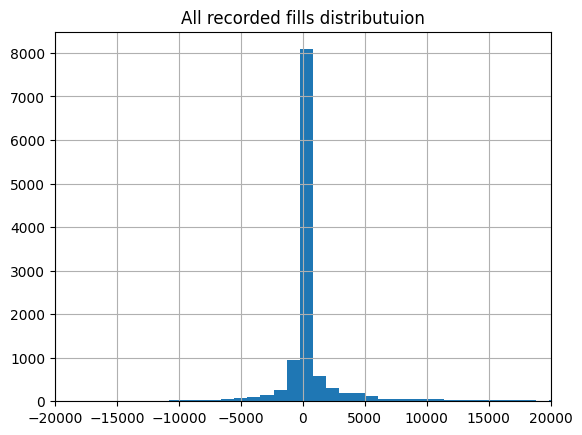

count     11792.000000
mean        456.035448
std        5134.175196
min     -270000.000000
25%         -44.000000
50%          11.000000
75%         241.000000
max      153143.000000
Name: volume, dtype: float64

In [5]:
from matplotlib import pyplot as plt 
hist_df = orders_df.copy()
hist_df.loc[hist_df['side'] == "SELL", 'volume'] *= -1

plt.hist(hist_df['volume'], bins=400)
plt.xlim(-20000, 20000)
plt.grid()
plt.title("All recorded fills distributuion")
plt.show()

hist_df['volume'].describe()

In [6]:
engine = create_engine(url)

orderbooks_df = pd.read_sql("orderbooks", engine)
orderbooks_df.head(1)

,id,ticker,class_code,timestamp,bids,asks,bid_volume,ask_volume
0,959197,SR320CE6A,OPTSPOT,2026-05-04 15:18:06+00:00,"[{'price': 1.33, 'quantity': 800}, {'price': 1...","[{'price': 1.68, 'quantity': 4000}, {'price': ...",136517,11968


In [7]:
orderbooks_df['timestamp'] = pd.to_datetime(orderbooks_df['timestamp'])
orderbooks_df.set_index('timestamp', inplace=True)
orderbooks_df.sort_index(inplace=True)
orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume
timestamp,,,,,,,
2026-03-23 15:39:07+00:00,32159,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1


In [8]:
orderbooks_df['best_bid'] = orderbooks_df['bids'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['best_ask'] = orderbooks_df['asks'].apply(lambda x: x[0]['price'] if x else None)
orderbooks_df['mid'] = (orderbooks_df['best_ask'] + orderbooks_df['best_bid'])/2

orderbooks_df.head(1)

,id,ticker,class_code,bids,asks,bid_volume,ask_volume,best_bid,best_ask,mid
timestamp,,,,,,,,,,
2026-03-23 15:39:07+00:00,32159,SR360CC6D,OPTSPOT,[],"[{'price': 0.54, 'quantity': 1}]",0,1,NaN,0.54,NaN


In [9]:
large_buy_orders['ts_adj'] = large_buy_orders.index + pd.Timedelta(microseconds=1)
df = pd.merge_asof(
    large_buy_orders.reset_index().sort_values('ts_adj'), 
    orderbooks_df[['ticker', 'best_bid', 'best_ask', 'mid']].reset_index(),
    left_on='ts_adj', 
    right_on = 'timestamp',
    by='ticker',
    direction='forward')

df.sort_values("volume", ascending=False).head()

,timestamp_x,id,ticker,class_code,side,volume,price,quantity,strike,ts_adj,timestamp_y,best_bid,best_ask,mid
40,2026-04-01 10:56:46+00:00,1879,SR310CD6B,OPTSPOT,BUY,153143,8,18451,310,2026-04-01 10:56:46.000001+00:00,2026-04-01 10:58:55+00:00,8.19,8.50,8.345
196,2026-05-06 13:48:07+00:00,10955,SR340CR6,OPTSPOT,BUY,89950,17,5000,340,2026-05-06 13:48:07.000001+00:00,2026-05-06 13:48:12+00:00,16.25,17.99,17.120
4,2026-03-25 11:46:13+00:00,381,SR310CD6,OPTSPOT,BUY,63350,12,5000,310,2026-03-25 11:46:13.000001+00:00,2026-03-25 11:46:14+00:00,12.00,12.68,12.340
0,2026-03-25 06:19:33+00:00,296,SR310CC6D,OPTSPOT,BUY,51150,9,5500,310,2026-03-25 06:19:33.000001+00:00,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
164,2026-04-24 19:06:47+00:00,8167,SR320CE6A,OPTSPOT,BUY,48182,8,5494,320,2026-04-24 19:06:47.000001+00:00,2026-04-24 19:06:48+00:00,8.77,8.78,8.775


In [10]:
df = df[['timestamp_x', 'ticker', 'volume', 'price', 'strike', 'timestamp_y', 'best_bid', 'best_ask', 'mid']]
df.head()

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810
1,2026-03-25 07:52:50+00:00,SR340CP6A,16672,20,340,2026-03-25 07:52:51+00:00,20.38,20.84,20.610
2,2026-03-25 08:53:17+00:00,SR340CP6A,16736,20,340,2026-03-25 08:53:18+00:00,20.38,21.09,20.735
3,2026-03-25 10:20:40+00:00,SR340CP6B,16320,20,340,2026-03-25 10:23:10+00:00,19.70,20.87,20.285
4,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,2026-03-25 11:46:14+00:00,12.00,12.68,12.340


In [22]:
horizons = [5, 30, 60, 120, 480, 720, 1440, 4320, 10080] #minues
#horizons = np.linspace(1, 10080, 20, dtype=int)
print(horizons)
for h in horizons:
    df['time_adj'] = df['timestamp_y'] + pd.Timedelta(minutes=h)
    merged = pd.merge_asof(
        df.sort_values('time_adj'),
        orderbooks_df.reset_index(),
        left_on = 'time_adj',
        right_on = 'timestamp',
        direction = 'nearest',
        tolerance = pd.Timedelta(minutes = h/2),
        by = 'ticker'
    ).sort_index() 
    df[f'best_ask_{h}'] = merged['best_ask_y']
    df[f'best_bid_{h}'] = merged['best_bid_y']
    df[f'mid_{h}'] = merged['mid_y']
    
df.head()

[5, 30, 60, 120, 480, 720, 1440, 4320, 10080]


C:\Users\bakae\AppData\Local\Temp\ipykernel_7852\2698096507.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'best_bid_{h}'] = merged['best_bid_y']
C:\Users\bakae\AppData\Local\Temp\ipykernel_7852\2698096507.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'mid_{h}'] = merged['mid_y']
C:\Users\bakae\AppData\Local\Temp\ipykernel_7852\2698096507.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining a

,timestamp_x,ticker,volume,price,strike,timestamp_y,best_bid,best_ask,mid,time_adj,...,mid_480,best_ask_720,best_bid_720,mid_720,best_ask_1440,best_bid_1440,mid_1440,best_ask_4320,best_bid_4320,mid_4320
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,2026-03-25 06:19:34+00:00,8.31,9.31,8.810,2026-04-01 06:19:34+00:00,...,7.235,8.70,6.63,7.665,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-25 07:52:50+00:00,SR340CP6A,16672,20,340,2026-03-25 07:52:51+00:00,20.38,20.84,20.610,2026-04-01 07:52:51+00:00,...,21.245,22.25,21.22,21.735,22.28,21.94,22.110,26.44,24.44,25.44
2,2026-03-25 08:53:17+00:00,SR340CP6A,16736,20,340,2026-03-25 08:53:18+00:00,20.38,21.09,20.735,2026-04-01 08:53:18+00:00,...,21.610,22.25,2.74,12.495,22.91,22.57,22.740,26.44,24.44,25.44
3,2026-03-25 10:20:40+00:00,SR340CP6B,16320,20,340,2026-03-25 10:23:10+00:00,19.70,20.87,20.285,2026-04-01 10:23:10+00:00,...,16.830,NaN,0.02,NaN,21.96,21.78,21.870,26.03,23.03,24.53
4,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,2026-03-25 11:46:14+00:00,12.00,12.68,12.340,2026-04-01 11:46:14+00:00,...,11.895,NaN,0.02,NaN,11.55,10.70,11.125,NaN,7.89,NaN


In [23]:
for h in horizons:
    df[f'mid_price_return_{h}'] = (df[f'mid_{h}'] - df['mid'])/df['mid']

C:\Users\bakae\AppData\Local\Temp\ipykernel_7852\1456302144.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'mid_price_return_{h}'] = (df[f'mid_{h}'] - df['mid'])/df['mid']


In [24]:
filtered_df = df.loc[df['strike'].astype(int) > 340]

snr_not_filtered = []
snr_filtered = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'].dropna()
    filtered_returns = df.loc[df['strike'].astype(int) > 330][f'mid_price_return_{h}'].dropna()

    print(f"h = {h}, count = {len(returns)}")
    mean = returns.mean()
    std = returns.std()
    snr_not_filtered.append(mean/std)

    mean = filtered_returns.mean()
    std = filtered_returns.std()
    snr_filtered.append(mean/std)

h = 5, count = 143
h = 30, count = 178
h = 60, count = 192
h = 120, count = 191
h = 480, count = 155
h = 720, count = 126
h = 1440, count = 159
h = 4320, count = 115
h = 10080, count = 161


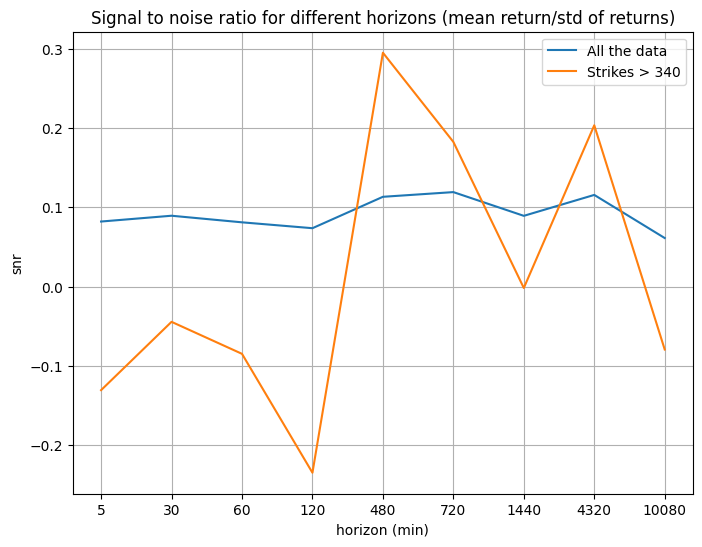

In [25]:
fig = plt.figure(figsize=(8,6))
plt.plot(range(len(horizons)), snr_not_filtered, label="All the data")
plt.plot(range(len(horizons)), snr_filtered, label="Strikes > 340")
plt.xticks(range(len(horizons)), horizons)
plt.grid()
plt.title("Signal to noise ratio for different horizons (mean return/std of returns)")
plt.xlabel("horizon (min)")
plt.ylabel("snr")
plt.legend()
plt.show()

In [26]:
stats = pd.DataFrame({
    'mean': [df[f'mid_price_return_{h}'].mean() for h in horizons],
    'std': [df[f'mid_price_return_{h}'].std() for h in horizons],
    'count': [df[f'mid_price_return_{h}'].notna().sum() for h in horizons],
    'mean_otm': [filtered_df[f'mid_price_return_{h}'].mean() for h in horizons],
    'std_otm': [filtered_df[f'mid_price_return_{h}'].std() for h in horizons],
    'count_otm': [filtered_df[f'mid_price_return_{h}'].notna().sum() for h in horizons]
}, index=horizons)
stats

,mean,std,count,mean_otm,std_otm,count_otm
5,0.035344,0.430238,143,0.000337,0.008066,8
30,0.182781,2.042910,178,-0.002830,0.011725,9
60,0.158570,1.953996,192,-0.006062,0.030500,9
120,0.149483,2.027156,191,-0.002800,0.036366,9
480,0.274174,2.418795,155,0.017134,0.040444,8
720,3.006564,25.206464,126,0.028410,0.037109,6
1440,0.205344,2.298491,159,0.060843,0.086275,2
4320,0.315954,2.730206,115,0.133208,NaN,1
10080,0.121186,1.976097,161,0.175557,0.087410,6


In [27]:
from scipy import stats

rows = []
for h in horizons:
    returns = df[f'mid_price_return_{h}'].dropna()
    t_stat, p_value = stats.ttest_1samp(returns, popmean=0)

    rows.append({
        'horizon': h,
        't_stat': t_stat,
        'p_value': p_value
    })

t_test_res = pd.DataFrame(rows)
t_test_res

,horizon,t_stat,p_value
0,5,0.982362,0.327592
1,30,1.193693,0.234196
2,60,1.124469,0.262225
3,120,1.019112,0.309446
4,480,1.411213,0.160199
5,720,1.338886,0.183037
6,1440,1.126515,0.261656
7,4320,1.241015,0.217148
8,10080,0.778140,0.437636


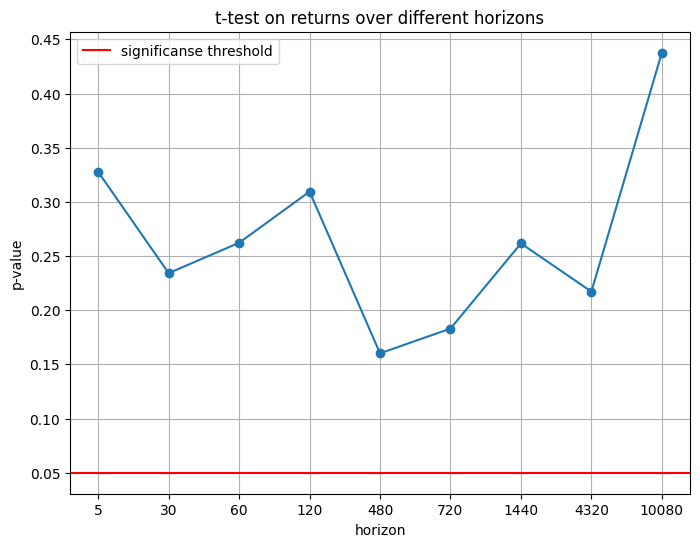

In [28]:
fig = plt.figure(figsize=(8,6))
plt.plot(range(len(horizons)), t_test_res['p_value'], marker="o")
plt.xticks(range(len(horizons)), horizons)
plt.xticks()
plt.grid()
plt.xlabel("horizon")
plt.ylabel("p-value")
plt.axhline(0.05, color='red', label="significanse threshold")
plt.title("t-test on returns over different horizons")
plt.legend()
plt.show()

In [57]:
df.columns[0:20]

cols = ['timestamp_x', 'ticker', 'volume', 'price', 'strike', 'best_ask'] + [f'best_bid_{h}' for h in horizons] 
backtest_df = df[cols]

for h in horizons:
    ask = backtest_df[f'best_ask']
    bid = backtest_df[f'best_bid_{h}']
    backtest_df[f'bid_ask_return_{h}'] = (bid - ask)/ask
backtest_df.head(1)

,timestamp_x,ticker,volume,price,strike,best_ask,best_bid_5,best_bid_30,best_bid_60,best_bid_120,...,best_bid_10080,bid_ask_return_5,bid_ask_return_30,bid_ask_return_60,bid_ask_return_120,bid_ask_return_480,bid_ask_return_720,bid_ask_return_1440,bid_ask_return_4320,bid_ask_return_10080
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,9.31,8.31,8.09,7.86,7.96,...,NaN,-0.107411,-0.131042,-0.155747,-0.145005,-0.286788,-0.287863,NaN,NaN,NaN


In [58]:
for h in horizons:
    backtest_df[f'equity_{h}'] = backtest_df[f'bid_ask_return_{h}'].cumsum()
backtest_df

,timestamp_x,ticker,volume,price,strike,best_ask,best_bid_5,best_bid_30,best_bid_60,best_bid_120,...,bid_ask_return_10080,equity_5,equity_30,equity_60,equity_120,equity_480,equity_720,equity_1440,equity_4320,equity_10080
0,2026-03-25 06:19:33+00:00,SR310CC6D,51150,9,310,9.31,8.31,8.09,7.86,7.96,...,NaN,-0.107411,-0.131042,-0.155747,-0.145005,-0.286788,-0.287863,NaN,NaN,NaN
1,2026-03-25 07:52:50+00:00,SR340CP6A,16672,20,340,20.84,NaN,NaN,20.38,20.67,...,0.102687,NaN,NaN,-0.177819,-0.153163,-0.295426,-0.269628,0.052783,0.172745,0.102687
2,2026-03-25 08:53:17+00:00,SR340CP6A,16736,20,340,21.09,NaN,20.67,20.67,20.93,...,0.089142,NaN,-0.150957,-0.197734,-0.160749,-0.301116,-1.139709,0.122959,0.331588,0.191829
3,2026-03-25 10:20:40+00:00,SR340CP6B,16320,20,340,20.87,16.78,NaN,16.78,20.17,...,0.045999,-0.303386,NaN,-0.393709,-0.194290,-0.784585,-2.138751,0.166562,0.435086,0.237828
4,2026-03-25 11:46:13+00:00,SR310CD6,63350,12,310,12.68,NaN,12.00,12.00,11.60,...,-0.295741,NaN,-0.204584,-0.447337,-0.279464,-0.869758,-3.137173,0.010410,0.057325,-0.057913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2026-05-06 13:48:07+00:00,SR340CR6,17990,17,340,17.99,NaN,NaN,15.73,4.46,...,-0.296276,NaN,NaN,11.985399,9.676109,-17.122534,-65.037844,7.658290,-34.676457,-7.659812
196,2026-05-06 13:48:07+00:00,SR340CR6,89950,17,340,17.99,NaN,NaN,15.73,4.46,...,-0.296276,NaN,NaN,11.859774,8.924024,-18.121422,-66.036732,7.593254,-35.675346,-7.956088
197,2026-05-07 14:42:08+00:00,SR320CQ6,20405,3,320,3.71,NaN,2.58,3.13,2.52,...,-0.851752,NaN,15.719024,11.703439,8.603270,-18.312797,-66.392527,7.482742,-36.408499,-8.807840
198,2026-05-07 18:16:10+00:00,SR310CQ6B,18480,0,310,0.49,NaN,0.17,0.17,0.17,...,NaN,NaN,15.065963,11.050378,7.950208,-19.210756,-67.290486,6.727640,-37.306458,NaN


Text(0, 0.5, 'Equity')

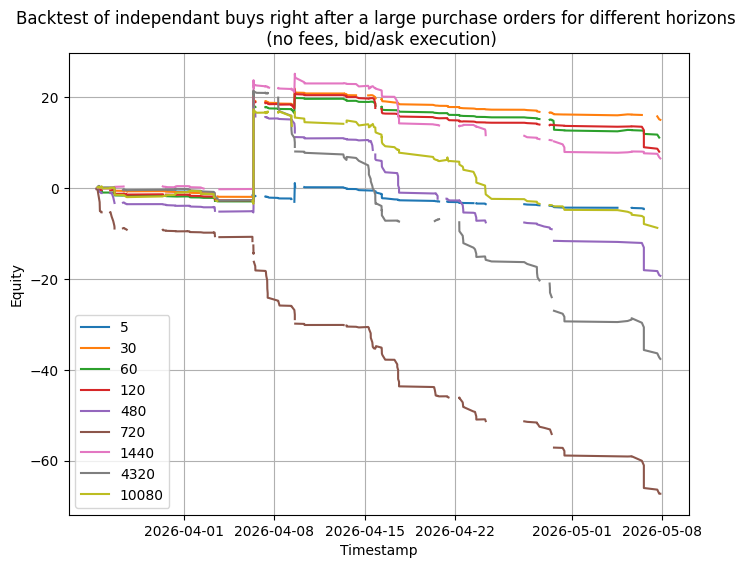

In [59]:
fig = plt.figure(figsize=(8,6))
for h in horizons:
    plt.plot(backtest_df['timestamp_x'], backtest_df[f'equity_{h}'], label=f"{h}")
plt.grid()
plt.legend()
plt.title("Backtest of independant buys right after a large purchase orders for different horizons \n (no fees, bid/ask execution)")
plt.xlabel("Timestamp")
plt.ylabel("Equity")

In [60]:
df_1440 = backtest_df[['timestamp_x', 'bid_ask_return_1440', 'equity_1440']]
df_1440['bid_ask_return_1440'].describe()

count    172.000000
mean       0.037557
std        1.812312
min       -0.999214
25%       -0.142207
50%       -0.043170
75%        0.036203
max       23.023810
Name: bid_ask_return_1440, dtype: float64

AttributeError: module 'matplotlib.pyplot' has no attribute 'gtid'

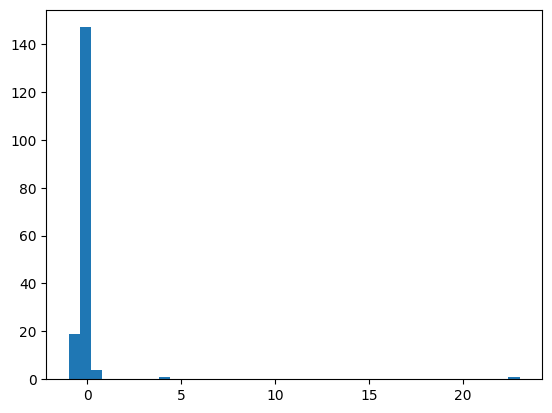

In [62]:
plt.hist(df_1440['bid_ask_return_1440'], bins=40)
plt.gtid()
plt.show()